In [2]:
import sys
import os
from pydataxm.pydatasimem import ReadSIMEM, CatalogSIMEM
import pandas as pd
import requests
import tempfile
from typing import List, Any, Dict, Union

# ---------------------------------------------------------
# 1. FUNCIÓN REUTILIZABLE PARA OBTENER nameColumns
# ---------------------------------------------------------
def obtener_namecolumns(dataset_id: str, url_template: str, timeout: int = 200) -> List[str]:

    if "{dataset_id}" not in url_template:
        raise ValueError("El url_template debe contener {dataset_id}")

    url = url_template.format(dataset_id=dataset_id)
    resp = requests.get(url, timeout=timeout)
    resp.raise_for_status()

    try:
        data = resp.json()
    except ValueError as e:
        raise ValueError(f"La respuesta no es JSON válido: {e}")

    if data is None:
        raise ValueError("La respuesta JSON está vacía (None).")

    # --- Recorrido recursivo ---
    def _find_namecolumns(obj: Union[Dict, List]) -> List[str]:
        found = []

        def _walk(node):
            if isinstance(node, dict):
                for k, v in node.items():
                    if k.lower() == "columns":  
                        if isinstance(v, list):
                            for item in v:
                                if isinstance(item, dict) and "nameColumn" in item:
                                    found.append(item["nameColumn"])
                        elif isinstance(v, dict):
                            for possible in ("items", "data", "list", "values"):
                                if possible in v and isinstance(v[possible], list):
                                    for item in v[possible]:
                                        if isinstance(item, dict) and "nameColumn" in item:
                                            found.append(item["nameColumn"])
                    _walk(v)
            elif isinstance(node, list):
                for n in node:
                    _walk(n)

        _walk(obj)

        # Únicos manteniendo el orden
        seen = set()
        unique = []
        for col in found:
            if col not in seen:
                seen.add(col)
                unique.append(col)
        return unique

    return _find_namecolumns(data)


# ---------------------------------------------------------
# 2. FUNCIÓN PRINCIPAL UNIFICADA
# ---------------------------------------------------------
def get_df_unificado(
    dataset_id: str,
    fecha_inicio: str,
    fecha_final: str,
    url_template_namecols: str,
    nombre_csv: str | None = None,
) -> Dict[str, Any]:
    """
    Descarga el dataset desde SIMEM, obtiene nameColumns vía API y guarda el CSV
    en un archivo temporal. El archivo temporal se crea con la librería
    estándar `tempfile` y se devuelve su ruta en el diccionario resultante.
    Si se especifica `nombre_csv`, se usará ese nombre dentro del directorio
    de almacenamiento (antigua conducta), pero por defecto se crean archivos
    temporales para no dejar residuos.

    La escritura del CSV se realiza **antes** de consultar el endpoint de
    columnas; cualquier fallo en esa llamada se captura y no evita el retorno
    del diccionario, de modo que siempre se puede inspeccionar `ruta_csv`.
    """

    # --- Obtener dataframe desde SIMEM ---
    catalogo = CatalogSIMEM(catalog_type='Datasets')
    df_catalogo = catalogo.get_data()

    simem = ReadSIMEM(dataset_id, fecha_inicio, fecha_final)
    df_general = simem.main()

    if df_general is None:
        print("Advertencia: ReadSIMEM.main() devolvió None. Se genera DataFrame vacío.")
        df_general = pd.DataFrame()

    # --- Determinar ruta de salida ---
    if nombre_csv:
        # comportamiento legado: escribir en carpeta Almacenamiento
        try:
            base_dir = os.path.dirname(os.path.abspath(__file__))
        except NameError:
            base_dir = os.getcwd()
        carpeta_dos_arriba = os.path.abspath(os.path.join(base_dir, "..", ".."))
        if not os.path.isdir(carpeta_dos_arriba):
            raise FileNotFoundError(
                f"No existe la carpeta dos niveles arriba: {carpeta_dos_arriba}"
            )
        carpeta_almacenamiento = os.path.join(carpeta_dos_arriba, "Almacenamiento")
        os.makedirs(carpeta_almacenamiento, exist_ok=True)
        ruta_csv = os.path.join(carpeta_almacenamiento, nombre_csv)
    else:
        # crear archivo temporal en el sistema (se mantiene tras cerrar)
        # el nombre devuelto se utiliza para almacenamiento externo y puede
        # inspeccionarse/leer desde otra parte del código o el notebook.
        tmp = tempfile.NamedTemporaryFile(prefix="simem_", suffix=".csv", delete=False)
        ruta_csv = tmp.name
        tmp.close()

    # Guardar CSV
    df_general.to_csv(ruta_csv, index=False, encoding="utf-8")
    print(f"CSV guardado en: {ruta_csv}")

    # --- Obtener columnas del endpoint; fallo no debe abortar ---
    try:
        namecolumns = obtener_namecolumns(dataset_id, url_template_namecols)
    except Exception as exc:  # pylint: disable=broad-except
        print(f"Advertencia: error al obtener nameColumns: {exc}")
        namecolumns = []

    # --- Retornar ambos resultados ---
    return {
        "dataframe": df_general,
        "namecolumns": namecolumns,
        "ruta_csv": ruta_csv,
    }

In [3]:
import re
from pathlib import Path
from typing import Dict, Optional, Any
import pandas as pd
import tempfile

ALMACEN_DIR = Path("Almacenamiento")  # Se creará si no existe


# -----------------------------
# Utilidades
# -----------------------------
def _sanitize_filename(text: Any) -> str:
    """Convierte un valor arbitrario en un nombre de archivo seguro."""
    if pd.isna(text):
        return "valor_vacio"
    s = str(text).strip().replace(" ", "_")
    # Elimina caracteres inválidos para nombres de archivo (Windows/Unix)
    s = re.sub(r'[\\/:*?"<>|]+', "", s)
    # Colapsa múltiples '_'
    s = re.sub(r"_+", "_", s)
    # Limita longitud por compatibilidad con distintos FS
    s = s[:120] if len(s) > 120 else s
    return s or "valor_vacio"


def _siguiente_ruta_disponible(base: Path) -> Path:
    """
    Dada una ruta base, si existe, genera base__1, base__2, ... hasta que no exista.
    Ej: 'col_val.csv' -> 'col_val__1.csv', etc.
    """
    if not base.exists():
        return base
    stem, suffix = base.stem, base.suffix
    contador = 1
    while True:
        candidata = base.with_name(f"{stem}__{contador}{suffix}")
        if not candidata.exists():
            return candidata
        contador += 1


def _elegir_columna_interactivo(df: pd.DataFrame) -> str:
    """Muestra columnas y permite elegir por número o por nombre (exacto)."""
    columnas = list(df.columns)
    print("\nColumnas disponibles:")
    for i, c in enumerate(columnas, start=1):
        print(f"  {i}. {c}")

    entrada = input("\nElige la columna (número o nombre exacto): ").strip()
    if not entrada:
        raise ValueError("No ingresaste una selección de columna.")

    # Intento por número
    if entrada.isdigit():
        idx = int(entrada)
        if not (1 <= idx <= len(columnas)):
            raise IndexError(f"Índice fuera de rango (1..{len(columnas)}).")
        return columnas[idx - 1]

    # Intento por nombre exacto (respeta mayúsculas/acentos)
    if entrada in df.columns:
        return entrada

    # Intento tolerante: ignorando espacios extremos
    candidato = entrada.strip()
    if candidato in df.columns:
        return candidato

    raise KeyError(f"La columna '{entrada}' no existe. Revisa la lista mostrada.")


def _elegir_valor_interactivo(serie: pd.Series) -> Any:
    """
    Lista valores únicos (preservando orden de aparición), muestra conteos y permite elegir uno.
    Retorna el valor real seleccionado (incluye NaN si se elige).
    """
    serie_obj = serie.astype("object")

    # Preserva orden de aparición
    valores_unicos = serie_obj.drop_duplicates(keep="first")

    # Asegura incluir NaN explícitamente si existe (y no está ya)
    if serie_obj.isna().any() and not valores_unicos.isna().any():
        valores_unicos = pd.concat([valores_unicos, pd.Series([float("nan")])], ignore_index=True)

    # Arma lista [(label, valor_real, conteo)]
    items = []
    for v in valores_unicos:
        if pd.isna(v):
            cnt = serie_obj.isna().sum()
            label = "NaN"
        else:
            cnt = (serie_obj == v).sum()
            label = str(v)
        items.append((label, v, cnt))

    # Métricas informativas
    unicos_con_nombre = [it for it in items if not pd.isna(it[1])]
    filas_nan = serie_obj.isna().sum()

    print("\nResumen de la columna seleccionada:")
    print(f"  - Valores con nombre (no vacíos): {len(unicos_con_nombre)}")
    print(f"  - Filas NaN (vacías): {filas_nan}")

    print("\nValores disponibles (en orden de aparición):")
    for i, (label, _valor, cnt) in enumerate(items, start=1):
        print(f"  {i}. {label}  →  {cnt} filas")

    entrada = input("\nElige el valor (número o etiqueta exacta mostrada): ").strip()
    if not entrada:
        raise ValueError("No ingresaste una selección de valor.")

    # Por número
    if entrada.isdigit():
        idx = int(entrada)
        if not (1 <= idx <= len(items)):
            raise IndexError(f"Índice fuera de rango (1..{len(items)}).")
        return items[idx - 1][1]

    # Por etiqueta exacta (la que imprimimos)
    for label, valor, _cnt in items:
        if entrada == label:
            return valor

    raise KeyError(f"El valor '{entrada}' no se encuentra en la lista mostrada.")


# -----------------------------
# Núcleo de exportación
# -----------------------------
def exportar_por_columna(
    df: pd.DataFrame,
    columna: str,
    carpeta_salida: Path | str | None = None,
    prefijo_archivo: Optional[str] = None,
    guardar_indice: bool = False,
    crear_carpeta_si_no_existe: bool = True,
    valor_objetivo: Optional[Any] = None,
):
    """
    Exporta CSV según 'valor_objetivo'.

    Por defecto (cuando `carpeta_salida` es None) cada resultado se guarda en
    un **archivo temporal** y el diccionario devuelto usa las rutas de dichos
    archivos. Si se proporciona `carpeta_salida` se seguirá el comportamiento
    clásico de escribir en disco dentro de esa carpeta (creándola si es
    necesario).

    Retorna:
        resultados -> dict con {ruta_archivo: filas}
        subset     -> df filtrado según el valor elegido
    """

    if not isinstance(df, pd.DataFrame):
        raise TypeError("El parámetro 'df' debe ser un pandas.DataFrame.")
    if columna not in df.columns:
        raise KeyError(f"La columna '{columna}' no existe. Columnas disponibles: {list(df.columns)}")

    usar_temp = carpeta_salida is None
    carpeta: Path | None = None
    if not usar_temp:
        # inicializar carpeta únicamente si no se usarán archivos temporales
        carpeta = Path(carpeta_salida)  # type: ignore[arg-type]
        if not carpeta.exists():
            if crear_carpeta_si_no_existe:
                carpeta.mkdir(parents=True, exist_ok=True)
            else:
                raise FileNotFoundError(f"La carpeta destino '{carpeta}' no existe.")

    # cuando usar_temp es True no se emplea la variable `carpeta` en absoluto

    serie = df[columna].astype("object")

    resultados = {}
    safe_prefix = _sanitize_filename((prefijo_archivo or columna).strip())

    # --- Exportar SOLO el valor elegido ---
    if valor_objetivo is not None:

        if pd.isna(valor_objetivo):
            mascara = serie.isna()
            etiqueta = "NaN"
        else:
            mascara = serie == valor_objetivo
            etiqueta = str(valor_objetivo)

        subset = df.loc[mascara]

        if subset.empty:
            return {}, subset

        safe_val = _sanitize_filename(etiqueta)
        if usar_temp:
            tmp = tempfile.NamedTemporaryFile(prefix=f"{safe_prefix}_{safe_val}_", suffix=".csv", delete=False)
            ruta_final = tmp.name
            tmp.close()
        else:
            assert carpeta is not None  # carpeta sólo puede ser None si usar_temp es True
            ruta = carpeta / f"{safe_prefix}_{safe_val}.csv"
            ruta_final = _siguiente_ruta_disponible(ruta)

        subset.to_csv(ruta_final, index=guardar_indice)
        resultados[str(ruta_final)] = len(subset)

        return resultados, subset  # ← DEVUELVE EL DATAFRAME FILTRADO

    # --- Exportar TODOS (modo clásico) ---
    valores_unicos = serie.drop_duplicates(keep="first")

    if serie.isna().any() and not valores_unicos.isna().any():
        valores_unicos = pd.concat([valores_unicos, pd.Series([float('nan')])], ignore_index=True)

    # Exportación en lote
    for val in valores_unicos:
        if pd.isna(val):
            mascara = serie.isna()
            etiqueta = "NaN"
        else:
            mascara = serie == val
            etiqueta = str(val)

        subset = df.loc[mascara]

        if subset.empty:
            continue

        safe_val = _sanitize_filename(etiqueta)
        if usar_temp:
            tmp = tempfile.NamedTemporaryFile(prefix=f"{safe_prefix}_{safe_val}_", suffix=".csv", delete=False)
            ruta_final = tmp.name
            tmp.close()
        else:
            assert carpeta is not None
            ruta = carpeta / f"{safe_prefix}_{safe_val}.csv"
            ruta_final = _siguiente_ruta_disponible(ruta)

        subset.to_csv(ruta_final, index=guardar_indice)
        resultados[str(ruta_final)] = len(subset)

    return resultados, df  # ← si exporta todo, devuelve df original

def ejecutar_interactivo(df: pd.DataFrame):
    print("=== Exportar CSV por un valor específico de una columna ===")
    print("Generando archivos temporales (no se usa carpeta fija)")

    columna = _elegir_columna_interactivo(df)
    print(f"\nTrabajando con la columna: {columna}")

    valor = _elegir_valor_interactivo(df[columna])

    resultados, df_seleccion = exportar_por_columna(
        df=df,
        columna=columna,
        carpeta_salida=None,
        prefijo_archivo=columna,
        guardar_indice=False,
        crear_carpeta_si_no_existe=True,
        valor_objetivo=valor
    )

    if not resultados:
        print("\n[INFO] No se generó archivo (subset vacío).")
        return df_seleccion

    total = sum(resultados.values())
    print(f"\n[OK] Se generó {len(resultados)} archivo(s).")
    print(f"[OK] Filas exportadas: {total}")

    for ruta, n in sorted(resultados.items()):
        print(f"  - {Path(ruta).name} → {n} filas")

    return df_seleccion  # ← AQUÍ DEVUELVE EL DF FILTRADO

In [4]:
import pandas as pd

def Separacion(columnas, archivo):
    """
    Separa un DataFrame en dos: uno con var_x y var_y (df_general), y otro con el resto (df_atributos).
    Permite renombrar interactivamente SOLO las dos columnas de df_general.

    Args:
        columnas: Lista de nombres de columnas disponibles (no usada, se valida desde el DataFrame).
        archivo: DataFrame de entrada.

    Returns:
        Tuple[pd.DataFrame, pd.DataFrame]: (df_general con 2 columnas, df_atributos con el resto)
    """
    # Validaciones iniciales
    if not isinstance(archivo, pd.DataFrame):
        raise TypeError(f"Se esperaba DataFrame, recibido: {type(archivo)}")
    if archivo.empty:
        raise ValueError("El DataFrame está vacío")

    # Columnas válidas desde el DataFrame real
    columnas_validas = list(archivo.columns)

    # --- Selección de variable X ---
    while True:
        var_x = input("Variable eje X: ").strip()
        if var_x in columnas_validas:
            break
        print(f"Columna no encontrada. Disponibles: {columnas_validas}")

    # --- Selección de variable Y ---
    while True:
        var_y = input("Variable eje Y: ").strip()
        if var_y == var_x:
            print("La variable Y no puede ser igual a X")
            continue
        if var_y in columnas_validas:
            break
        print(f"Columna no encontrada. Disponibles: {columnas_validas}")

    # --- Construcción de df_general y df_atributos ---
    df_general = archivo[[var_x, var_y]].copy()

    # Convertir X a datetime (intento estricto + flexible)
    try:
        df_general[var_x] = pd.to_datetime(df_general[var_x], format='%Y-%m-%d %H:%M:%S')
    except Exception:
        df_general[var_x] = pd.to_datetime(df_general[var_x], errors='coerce', dayfirst=False)

    df_atributos = archivo.drop([var_x, var_y], axis=1).copy()

    # --- Renombrado interactivo de SOLO X e Y ---
    print("\n=== Renombrar columnas de df_general (solo X e Y) ===")
    print(f"Nombre actual de X: {var_x}")
    nuevo_x = input("Nuevo nombre para X (Enter para conservar): ").strip()
    if not nuevo_x:
        nuevo_x = var_x

    print(f"Nombre actual de Y: {var_y}")
    nuevo_y = input("Nuevo nombre para Y (Enter para conservar): ").strip()
    if not nuevo_y:
        nuevo_y = var_y

    # Validaciones de los nuevos nombres
    if not nuevo_x:
        raise ValueError("El nombre para X no puede ser vacío.")
    if not nuevo_y:
        raise ValueError("El nombre para Y no puede ser vacío.")
    if nuevo_x == nuevo_y:
        raise ValueError("Los nombres de X e Y no pueden ser iguales.")

    # Aplicar renombre en df_general
    df_general.rename(columns={var_x: nuevo_x, var_y: nuevo_y}, inplace=True)

    # Validaciones finales
    assert isinstance(df_general, pd.DataFrame), "df_general no es DataFrame"
    assert isinstance(df_atributos, pd.DataFrame), "df_atributos no es DataFrame"
    assert df_general.shape[1] == 2, f"df_general debe tener 2 columnas, tiene {df_general.shape[1]}"

    return df_general, df_atributos

In [5]:
from __future__ import annotations
import io
import re
import json
import csv
import configparser
from pathlib import Path
from typing import Optional, Tuple, Dict, Any, List

import pandas as pd
import xml.etree.ElementTree as ET

try:
    import yaml  # opcional, para YAML
    HAS_YAML = True
except ImportError:
    yaml = None
    HAS_YAML = False


# -------------------------
# Utilidades generales
# -------------------------

COMMON_ENCODINGS = ("utf-8", "latin-1", "cp1252")

def _try_read_text(path: Path, max_bytes: int = 100_000) -> Tuple[str, str]:
    """Lee un fragmento del archivo intentando varias codificaciones. Devuelve (texto, encoding)."""
    data = Path(path).read_bytes()[:max_bytes]
    for enc in COMMON_ENCODINGS:
        try:
            return data.decode(enc), enc
        except UnicodeDecodeError:
            continue
    # último recurso: reemplazar caracteres inválidos
    return data.decode("utf-8", errors="replace"), "utf-8"

def _detect_by_extension(path: Path) -> Optional[str]:
    ext = path.suffix.lower()
    if ext in {".csv"}:
        return "csv"
    if ext in {".tsv"}:
        return "tsv"
    if ext in {".json"}:
        return "json"
    if ext in {".xml"}:
        return "xml"
    if ext in {".yaml", ".yml"}:
        return "yaml"
    if ext in {".ini", ".cfg", ".conf"}:
        return "ini"
    if ext in {".log"}:
        return "log"
    if ext in {".txt"}:
        return "txt"
    return None

CSV_LIKE_SEPS = [",", ";", "\t", "|", ":"]

def _sniff_delimiter(sample: str) -> Optional[str]:
    """Intenta detectar un delimitador probable a partir de un texto de muestra."""
    # Probar csv.Sniffer primero
    try:
        dialect = csv.Sniffer().sniff(sample, delimiters="".join(CSV_LIKE_SEPS))
        return dialect.delimiter
    except Exception:
        pass
    # Heurística: contar separadores por línea y elegir el más consistente
    lines = [ln for ln in sample.splitlines() if ln.strip()]
    lines = lines[:50]  # limitar
    counts = {sep: 0 for sep in CSV_LIKE_SEPS}
    for ln in lines:
        for sep in CSV_LIKE_SEPS:
            counts[sep] += ln.count(sep)
    # Elegir separador con mayor conteo total y que aparezca en varias líneas
    best = max(counts.items(), key=lambda kv: kv[1])
    if best[1] >= 3:  # umbral mínimo
        return best[0]
    return None

def _looks_like_json(sample: str) -> bool:
    s = sample.lstrip()
    return s.startswith("{") or s.startswith("[")

def _looks_like_xml(sample: str) -> bool:
    return sample.lstrip().startswith("<")

def _looks_like_ini(sample: str) -> bool:
    return bool(re.search(r"^\s*\[.+?\]\s*$", sample, flags=re.MULTILINE))

def _looks_like_yaml(sample: str) -> bool:
    # Heurística simple: líneas clave: valor y/o listas con '- '
    k_v = len(re.findall(r"^[\w\-\.]+\s*:\s*.+$", sample, flags=re.MULTILINE))
    dashed = len(re.findall(r"^\s*-\s+.+$", sample, flags=re.MULTILINE))
    return (k_v + dashed) >= 3

APACHE_LOG_PATTERN = re.compile(
    r'(?P<host>\S+) (?P<ident>\S+) (?P<user>\S+) \[(?P<time>[^\]]+)\] '
    r'"(?P<request>[^"]*)" (?P<status>\d{3}) (?P<size>\S+)(?: '
    r'"(?P<referrer>[^"]*)" "(?P<agent>[^"]*)")?'
)

def _looks_like_apache_log(sample: str) -> bool:
    for ln in sample.splitlines()[:10]:
        if APACHE_LOG_PATTERN.search(ln):
            return True
    return False


# -------------------------
# Lectores específicos
# -------------------------

def _read_csv_like(path: Path, encoding_hint: Optional[str], sep_hint: Optional[str]) -> pd.DataFrame:
    # pandas infiere compresión por extensión (gz, bz2, zip, xz)
    encodings_to_try = [encoding_hint] + [e for e in COMMON_ENCODINGS if e != encoding_hint] if encoding_hint else list(COMMON_ENCODINGS)
    seps_to_try = [sep_hint] + [s for s in CSV_LIKE_SEPS if s != sep_hint] if sep_hint else CSV_LIKE_SEPS
    errors = []
    for enc in encodings_to_try:
        for sep in seps_to_try:
            try:
                return pd.read_csv(path, sep=sep, encoding=enc, engine="python")
            except Exception as ex:
                errors.append((enc, sep, str(ex)))
    # Último intento: dejar que pandas infiera con sep=None (solo Python engine)
    for enc in encodings_to_try:
        try:
            return pd.read_csv(path, sep=None, engine="python", encoding=enc)
        except Exception as ex:
            errors.append((enc, "auto", str(ex)))
    raise RuntimeError(f"No fue posible leer como CSV/TSV. Intentos: {len(errors)}. Ejemplo de error: {errors[-1] if errors else 'N/A'}")

def _json_to_records(obj: Any) -> List[Dict[str, Any]]:
    # Si es lista de dicts → listo
    if isinstance(obj, list):
        if all(isinstance(it, dict) for it in obj):
            return obj
        # lista de valores -> envolver
        return [{"value": it} for it in obj]
    # Si es dict, buscar la primera clave que sea lista de dicts
    if isinstance(obj, dict):
        for k, v in obj.items():
            if isinstance(v, list) and all(isinstance(it, dict) for it in v):
                return v
        # Sin listas de dicts -> aplanar dict en una sola fila
        flat = {}
        for k, v in obj.items():
            if isinstance(v, (dict, list)):
                flat[k] = json.dumps(v, ensure_ascii=False)
            else:
                flat[k] = v
        return [flat]
    # Cualquier otro → fila única
    return [{"value": obj}]

def _read_json(path: Path, encoding_hint: Optional[str]) -> pd.DataFrame:
    text, enc = _try_read_text(path) if encoding_hint is None else (Path(path).read_text(encoding=encoding_hint), encoding_hint)
    try:
        data = json.loads(text)
    except json.JSONDecodeError as ex:
        # pandas también puede leer JSON línea por línea (jsonlines)
        try:
            return pd.read_json(path, lines=True, encoding=enc)
        except Exception:
            raise ex
    records = _json_to_records(data)
    return pd.DataFrame.from_records(records)

def _read_xml(path: Path, encoding_hint: Optional[str]) -> pd.DataFrame:
    # 1) Intentar con pandas.read_xml (si lxml/etree lo permite)
    try:
        return pd.read_xml(path)  # pandas intentará inferir estructura
    except Exception:
        pass
    # 2) Heurística con ElementTree: elegir el tag más repetido como "fila"
    text, _ = _try_read_text(path)
    root = ET.fromstring(text)
    # Contar ocurrencias por etiqueta (ignorando root)
    from collections import Counter, defaultdict
    tag_counts = Counter()
    elements_by_tag = defaultdict(list)
    for elem in root.iter():
        if elem is root:
            continue
        tag_counts[elem.tag] += 1
        elements_by_tag[elem.tag].append(elem)
    if not tag_counts:
        # XML vacío o trivial
        return pd.DataFrame()
    candidate_tag, _ = tag_counts.most_common(1)[0]
    rows = []
    for el in elements_by_tag[candidate_tag]:
        row = {}
        # atributos
        for k, v in el.attrib.items():
            row[k] = v
        # hijos directos como columnas
        for child in list(el):
            key = child.tag
            val = (child.text or "").strip() if child.text else ""
            # si el hijo tiene subhijos, serializar JSON
            if list(child):
                val = json.dumps({c.tag: (c.text or "").strip() for c in child}, ensure_ascii=False)
            row[key] = val
        # texto directo del elemento
        if not row and (el.text or "").strip():
            row["value"] = el.text.strip()
        rows.append(row)
    return pd.DataFrame(rows)

def _read_yaml(path: Path, encoding_hint: Optional[str]) -> pd.DataFrame:
    if not HAS_YAML or yaml is None:
        raise ImportError("PyYAML no está instalado. Instálalo con: pip install pyyaml")
    text, enc = _try_read_text(path) if encoding_hint is None else (Path(path).read_text(encoding=encoding_hint), encoding_hint)
    data = yaml.safe_load(text)
    records = _json_to_records(data)
    return pd.DataFrame.from_records(records)

def _read_ini(path: Path, encoding_hint: Optional[str]) -> pd.DataFrame:
    encodings_to_try = [encoding_hint] + [e for e in COMMON_ENCODINGS if e != encoding_hint] if encoding_hint else list(COMMON_ENCODINGS)
    parser = configparser.ConfigParser()
    for enc in encodings_to_try:
        try:
            with open(path, "r", encoding=enc) as f:
                parser.read_file(f)
            break
        except Exception:
            continue
    rows = []
    for section in parser.sections():
        for option, value in parser.items(section):
            rows.append({"section": section, "option": option, "value": value})
    return pd.DataFrame(rows)

def _read_log(path: Path, encoding_hint: Optional[str]) -> pd.DataFrame:
    text, enc = _try_read_text(path) if encoding_hint is None else (Path(path).read_text(encoding=encoding_hint), encoding_hint)
    lines = [ln for ln in text.splitlines() if ln.strip()]
    # Intentar Apache/Nginx common/combined
    matches = [APACHE_LOG_PATTERN.search(ln) for ln in lines]
    if any(m is not None for m in matches):
        records = []
        for m in matches:
            if not m:
                continue
            rec = m.groupdict()
            # convertir size a int si aplica
            if rec.get("size") and rec["size"].isdigit():
                rec["size"] = int(rec["size"])
            records.append(rec)
        return pd.DataFrame(records)
    # Heurística: intentar key=value
    kv_pattern = re.compile(r"(\b[\w\.-]+)=(\"[^\"]*\"|\S+)")
    kv_records = []
    for ln in lines:
        pairs = dict((k, v.strip('"')) for k, v in kv_pattern.findall(ln))
        if pairs:
            kv_records.append(pairs)
    if kv_records:
        return pd.DataFrame(kv_records)
    # Fallback: una columna con el texto
    return pd.DataFrame({"line": lines})

# -------------------------
# Cargador principal
# -------------------------

def load_to_dataframe(path: str | Path) -> pd.DataFrame:
    """
    Detecta el formato del archivo y lo carga como DataFrame.
    Devuelve solo el DataFrame.
    """
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo: {path}")

    sample_text, enc = _try_read_text(path)
    fmt = _detect_by_extension(path)

    # Si no se determinó por extensión, usar heurísticas de contenido
    if fmt is None:
        if _looks_like_json(sample_text):
            fmt = "json"
        elif _looks_like_xml(sample_text):
            fmt = "xml"
        elif _looks_like_ini(sample_text):
            fmt = "ini"
        elif _looks_like_yaml(sample_text):
            fmt = "yaml"
        elif _looks_like_apache_log(sample_text):
            fmt = "log"
        else:
            # ¿Tabular?
            sep = _sniff_delimiter(sample_text)
            if sep:
                fmt = "csv" if sep != "\t" else "tsv"
            else:
                fmt = "txt"

    # Lectura por formato
    sep_hint = _sniff_delimiter(sample_text) if fmt in {"csv", "tsv", "txt"} else None

    if fmt in {"csv", "tsv"}:
        df = _read_csv_like(path, enc, sep_hint or ("," if fmt == "csv" else "\t"))
    elif fmt == "json":
        df = _read_json(path, enc)
    elif fmt == "xml":
        df = _read_xml(path, enc)
    elif fmt == "yaml":
        df = _read_yaml(path, enc)
    elif fmt == "ini":
        df = _read_ini(path, enc)
    elif fmt == "log":
        df = _read_log(path, enc)
    elif fmt == "txt":
        # Intentar tabular; si no, columna única
        if sep_hint:
            df = _read_csv_like(path, enc, sep_hint)
        else:
            lines = [ln for ln in sample_text.splitlines() if ln.strip()]
            df = pd.DataFrame({"text": lines})
    else:
        raise ValueError(f"Formato no soportado o no reconocido: {fmt}")

    return df

In [6]:
import pandas as pd
import tempfile

def obtener_columnas_df(df: pd.DataFrame) -> list:
    """
    Retorna la lista de nombres de columnas de un DataFrame.

    Args:
        df (pd.DataFrame): DataFrame del que se quieren las columnas.

    Returns:
        list: nombres de las columnas.
    """
    if df is None:
        raise ValueError("El DataFrame no puede ser None")
    columnas = df.columns.tolist()
    print(f"Columnas del DataFrame: {columnas}")
    return columnas

# si aún se necesita leer desde un archivo plano
def obtener_columnas_archivo(ruta_archivo, crear_temp: bool = True):
    """
    Lee un archivo plano y retorna sus columnas.

    Si `crear_temp` es True se genera un archivo temporal con sólo las
    cabeceras (mismas columnas) y se devuelve la ruta junto con la lista de
    columnas; esto asegura que cualquier fichero que produzca este código sea
    temporal y no deje residuos.

    Args:
        ruta_archivo (str): camino al archivo CSV.
        crear_temp (bool): controla la creación del fichero temporal.

    Returns:
        tuple[list, Optional[str]]: (columnas, ruta_temp)
    """
    try:
        df = pd.read_csv(ruta_archivo, sep=',', nrows=1)  # ajustar sep si hace falta
        columnas = df.columns.tolist()
        print(f"Columnas encontradas: {columnas}")

        ruta_temp = None
        if crear_temp:
            tmp = tempfile.NamedTemporaryFile(prefix="cols_", suffix=".csv", delete=False)
            df.head(0).to_csv(tmp.name, index=False)
            ruta_temp = tmp.name
            tmp.close()
            print(f"Archivo temporal creado: {ruta_temp}")

        return columnas, ruta_temp
    except FileNotFoundError:
        print(f"Error: No se encontró el archivo en {ruta_archivo}")
        return [], None
    except Exception as e:
        print(f"Error al leer el archivo: {e}")
        return [], None




In [7]:
# -*- coding: utf-8 -*-
from __future__ import annotations
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Optional, Tuple, Dict, Any

# =========================
# Helpers internos
# =========================

def _parse_col_fecha(
    df: pd.DataFrame,
    x_col: str,
    *,
    date_format: Optional[str],
    dayfirst: bool,
    strict_parse: bool,
    sintetizar_si_no_hay_fecha: bool,
    sintetico_origen: str
) -> Tuple[pd.DataFrame, str]:
    """
    Devuelve (df_con_fecha_parseada, nombre_col_fecha).
    Si x_col no existe, intenta con la primera columna.
    Si no puede parsear y se permite sintetizar, crea una secuencia diaria.
    """
    if df is None or df.empty:
        return df, x_col

    tmp = df.copy()
    errors_mode = "raise" if strict_parse else "coerce"

    if x_col in tmp.columns:
        col = x_col
    else:
        col = tmp.columns[0]  # fallback a primera columna

    try:
        tmp[col] = pd.to_datetime(tmp[col], format=date_format, dayfirst=dayfirst, errors=errors_mode)
    except Exception as e:
        if not sintetizar_si_no_hay_fecha:
            raise ValueError(
                f"No existe '{x_col}' o no se pudo parsear la columna '{col}' como fecha: {e}\n"
                "Sugerencia: indica 'x_col' correcto o provee 'date_format' adecuado; "
                "si quieres inventar fechas, activa sintetizar_si_no_hay_fecha=True."
            )
        # Sintetizar fechas (no recomendado salvo debugging)
        tmp = tmp.reset_index(drop=True)
        base = pd.to_datetime(sintetico_origen)
        tmp[col] = base + pd.to_timedelta(np.arange(len(tmp)), unit="D")

    # Quitar NAs en la fecha
    tmp = tmp.dropna(subset=[col])

    return tmp, col


def _obtener_cols_valor(
    df: pd.DataFrame,
    fecha_col_name: str,
    y_cols: Optional[List[str]]
) -> List[str]:
    """Determina columnas 'valor' automáticamente si y_cols es None."""
    if y_cols is None:
        if "valor" in df.columns:
            return ["valor"]
        # Todas las numéricas excepto la fecha
        return [c for c in df.columns if c != fecha_col_name and pd.api.types.is_numeric_dtype(df[c])]
    else:
        return [c for c in y_cols if c in df.columns and c != fecha_col_name]


def _normalizar_minmax_por_serie(largo: pd.DataFrame) -> pd.DataFrame:
    """Normaliza valor a [0,1] por serie (min-max). Si rango=0, pone 0."""
    def _scale(g: pd.DataFrame) -> pd.DataFrame:
        vmin, vmax = g["valor"].min(), g["valor"].max()
        rng = vmax - vmin
        if rng == 0 or not np.isfinite(rng):
            g["valor"] = 0.0
        else:
            g["valor"] = (g["valor"] - vmin) / rng
        return g
    return largo.groupby("serie", group_keys=False).apply(_scale)


# =========================
# Núcleo de preparación
# =========================

def preparar_largo_desde_lista(
    dfs: List[pd.DataFrame],
    x_col: str = "fecha",
    y_cols: Optional[List[str]] = None,
    label_col: Optional[str] = None,
    max_series: int = 5,
    sintetizar_si_no_hay_fecha: bool = False,
    sintetico_origen: str = "1970-01-01",
    date_format: Optional[str] = None,
    dayfirst: bool = False,
    strict_parse: bool = True,
    *,
    verbose: bool = True,
    retornar_diag: bool = False
) -> pd.DataFrame | Tuple[pd.DataFrame, pd.DataFrame]:
    """
    Convierte una lista de DataFrames a formato largo [fecha, valor, serie].
    - Si no encuentra x_col, usa la PRIMERA COLUMNA como fecha (sin inventar, salvo que se autorice).
    - Limita a max_series para evitar saturación.
    - Si label_col existe en el DF, conserva el comportamiento original: para cada col de valor, 
      se agregan registros bajo el MISMO nombre de serie proveniente de label_col (potencial colisión intencional).
    Retorna:
      - largo o (largo, diag) si retornar_diag=True.
    """
    largos: List[pd.DataFrame] = []
    serie_count = 0

    for i, df in enumerate(dfs, start=1):
        if df is None or df.empty:
            continue

        tmp, fecha_col_name = _parse_col_fecha(
            df, x_col,
            date_format=date_format,
            dayfirst=dayfirst,
            strict_parse=strict_parse,
            sintetizar_si_no_hay_fecha=sintetizar_si_no_hay_fecha,
            sintetico_origen=sintetico_origen
        )

        cols_val = _obtener_cols_valor(tmp, fecha_col_name, y_cols)
        if not cols_val:
            continue

        # -------- Rama con label_col ----------
        if label_col and (label_col in tmp.columns):
            # Conservamos semántica original: cada columna de valor se vuelca bajo el mismo nombre de serie=label
            # Esto colapsa múltiples columnas en la misma etiqueta; es intencional por compatibilidad.
            for col in cols_val:
                sub = tmp[[fecha_col_name, col, label_col]].dropna(subset=[fecha_col_name, col, label_col])
                if sub.empty:
                    continue
                sub = sub.rename(columns={fecha_col_name: "fecha", col: "valor", label_col: "serie"})
                # Cast a string para estabilidad en leyendas
                sub["serie"] = sub["serie"].astype(str)
                largos.append(sub[["fecha", "valor", "serie"]])
                serie_count += sub["serie"].nunique()
                if serie_count >= max_series:
                    break
        else:
            # Sin label_col: cada columna de valor es una serie distinta
            for col in cols_val:
                sub = tmp[[fecha_col_name, col]].dropna(subset=[fecha_col_name, col])
                if sub.empty:
                    continue
                parte = sub.rename(columns={fecha_col_name: "fecha", col: "valor"})
                parte["serie"] = f"{col}"
                largos.append(parte[["fecha", "valor", "serie"]])
                serie_count += 1
                if serie_count >= max_series:
                    break

        if serie_count >= max_series:
            break

    if not largos:
        raise ValueError("No se encontraron series válidas para graficar.")

    largo = pd.concat(largos, ignore_index=True)

    # Agregado por duplicados exactos (fecha, serie)
    largo = (largo
             .groupby(["fecha", "serie"], as_index=False, sort=False)["valor"].mean()
             .sort_values("fecha"))

    # Diagnóstico (opcional)
    diag = (largo.groupby("serie")["fecha"]
            .agg(fecha_min="min", fecha_max="max", n="count")
            .reset_index())

    if verbose:
        try:
            with pd.option_context("display.max_rows", None, "display.width", 120):
                print("Diagnóstico de fechas por serie:")
                print(diag.to_string(index=False))
        except Exception:
            print("Diagnóstico de fechas por serie:")
            print(diag)

    return (largo, diag) if retornar_diag else largo


# =========================
# Visualizaciones
# =========================

def _plot_lineas_desde_largo(
    largo: pd.DataFrame,
    *,
    titulo: str = "Comparación de series",
    unidad: str = "",
    normalizar: bool = False,
    figsize: Tuple[int, int] = (12, 6)
) -> Tuple[plt.Figure, plt.Axes]:
    """Dibuja líneas superpuestas desde un DF largo estándar."""
    sns.set(style="whitegrid")

    data = largo.copy()
    if normalizar:
        data = _normalizar_minmax_por_serie(data)

    fig, ax = plt.subplots(figsize=figsize)

    for serie, sub in data.groupby("serie", sort=False):
        sub = sub.sort_values("fecha")
        ax.plot(sub["fecha"], sub["valor"], label=str(serie), linewidth=2)

    xmin, xmax = data["fecha"].min(), data["fecha"].max()
    ax.set_xlim(left=xmin, right=xmax)

    ax.set_title(titulo + (" (normalizado)" if normalizar else ""), fontsize=15)
    ax.set_xlabel("Tiempo")
    ax.set_ylabel(f"Valor {unidad}".strip())
    ax.legend(ncol=2, frameon=True, fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()
    return fig, ax


def plot_series_desde_lista(
    dfs: List[pd.DataFrame],
    x_col: str = "fecha",
    y_cols: Optional[List[str]] = None,
    label_col: Optional[str] = None,
    titulo: str = "Comparación de series",
    unidad: str = "",
    normalizar: bool = False,
    apilado: bool = False,
    max_series: int = 5,
    figsize: Tuple[int, int] = (12, 6),
    sintetizar_si_no_hay_fecha: bool = False,
    sintetico_origen: str = "1970-01-01",
    date_format: Optional[str] = None,
    dayfirst: bool = False,
    strict_parse: bool = True,
    *,
    verbose: bool = True,
    retornar_diag: bool = False
) -> Tuple[plt.Figure, plt.Axes, pd.DataFrame, Optional[pd.DataFrame]]:
    """
    Lee lista de DFs, prepara largo y grafica (líneas o área apilada).
    Devuelve (fig, ax, largo, diag_opcional).
    """
    largo, diag = preparar_largo_desde_lista(
        dfs, x_col=x_col, y_cols=y_cols, label_col=label_col, max_series=max_series,
        sintetizar_si_no_hay_fecha=sintetizar_si_no_hay_fecha,
        sintetico_origen=sintetico_origen,
        date_format=date_format,
        dayfirst=dayfirst,
        strict_parse=strict_parse,
        verbose=verbose,
        retornar_diag=True
    )

    sns.set(style="whitegrid")
    fig, ax = plt.subplots(figsize=figsize)

    data = largo.copy()
    if apilado:
        # Área apilada (normalizar=True NO hace stacking porcentual; conserva magnitudes)
        piv = data.pivot(index="fecha", columns="serie", values="valor").sort_index().fillna(0.0)
        if normalizar:
            # Normalización min-max por serie (columna)
            piv = (piv - piv.min()) / (piv.max() - piv.min()).replace({0.0: np.nan}).fillna(0.0)
        x = piv.index
        ys = piv.values.T
        labels = list(piv.columns.astype(str))
        ax.stackplot(x, *ys, labels=labels, alpha=0.85)
    else:
        # Líneas superpuestas
        if normalizar:
            data = _normalizar_minmax_por_serie(data)
        for serie, sub in data.groupby("serie", sort=False):
            sub = sub.sort_values("fecha")
            ax.plot(sub["fecha"], sub["valor"], label=str(serie), linewidth=2)

    xmin, xmax = data["fecha"].min(), data["fecha"].max()
    ax.set_xlim(left=xmin, right=xmax)

    ax.set_title(titulo + (" (normalizado)" if normalizar else ""), fontsize=15)
    ax.set_xlabel("Tiempo")
    ax.set_ylabel(f"Valor {unidad}".strip())
    ax.legend(ncol=2, frameon=True, fontsize=9)
    fig.autofmt_xdate()
    plt.tight_layout()

    if retornar_diag:
        return fig, ax, largo, diag
    return fig, ax, largo, None


def _plot_boxplot_mensual_desde_largo(
    largo: pd.DataFrame,
    unidad: str = "",
    titulo: str = "Distribución mensual (boxplot) de valores",
    showfliers: bool = False,
    figsize: Tuple[int, int] = (12, 5)
) -> Tuple[plt.Figure, plt.Axes]:
    """Boxplot por mes a partir de 'fecha' y 'valor'."""
    df = largo.copy().dropna(subset=["fecha", "valor"])
    if df.empty:
        raise ValueError("No hay datos para boxplot mensual.")
    df["Mes"] = pd.to_datetime(df["fecha"]).dt.to_period("M").dt.to_timestamp()

    orden = sorted(df["Mes"].dropna().unique().tolist())
    fig, ax = plt.subplots(figsize=figsize)
    sns.boxplot(ax=ax, data=df, x="Mes", y="valor", order=orden, whis=1.5, showfliers=showfliers)
    for label in ax.get_xticklabels():
        label.set_rotation(90)
    ax.set_title(titulo)
    ax.set_xlabel("Mes")
    ax.set_ylabel(f"Valor {unidad}".strip())
    plt.tight_layout()
    return fig, ax


def plot_inteligente(
    dfs: List[pd.DataFrame],
    x_col: str = "fecha",
    y_cols: Optional[List[str]] = None,
    label_col: Optional[str] = None,
    titulo: str = "Visualización inteligente",
    unidad: str = "",
    normalizar: bool = False,
    apilado: bool = False,
    max_series: int = 5,
    figsize: Tuple[int, int] = (12, 6),
    sintetizar_si_no_hay_fecha: bool = False,
    sintetico_origen: str = "1970-01-01",
    date_format: Optional[str] = None,
    dayfirst: bool = False,
    strict_parse: bool = True,
    mostrar: Optional[List[str]] = None,
    *,
    verbose: bool = True
) -> Dict[str, Any]:
    """
    Orquesta automáticamente:
      - Si hay UNA sola fecha ⇒ usa plot_series_desde_lista (líneas o apilado).
      - Si hay MÚLTIPLES fechas ⇒ genera en orden: 'lineas' y/o 'boxplot'.
    Retorna dict con handlers: {'largo', 'diag', 'lineas', 'apilado', 'boxplot'} según corresponda.
    """
    largo, diag = preparar_largo_desde_lista(
        dfs,
        x_col=x_col,
        y_cols=y_cols,
        label_col=label_col,
        max_series=max_series,
        sintetizar_si_no_hay_fecha=sintetizar_si_no_hay_fecha,
        sintetico_origen=sintetico_origen,
        date_format=date_format,
        dayfirst=dayfirst,
        strict_parse=strict_parse,
        verbose=verbose,
        retornar_diag=True
    )

    n_fechas = largo["fecha"].nunique(dropna=True)
    if verbose:
        print(f"Fechas únicas detectadas: {n_fechas}")

    resultados: Dict[str, Any] = {"largo": largo, "diag": diag}

    if n_fechas <= 1:
        if verbose:
            print("Caso detectado: una sola fecha. Usando plot_series_desde_lista()...")
        fig, ax, _, _ = plot_series_desde_lista(
            dfs=dfs,
            x_col=x_col,
            y_cols=y_cols,
            label_col=label_col,
            titulo=titulo,
            unidad=unidad,
            normalizar=normalizar,
            apilado=apilado,
            max_series=max_series,
            figsize=figsize,
            sintetizar_si_no_hay_fecha=sintetizar_si_no_hay_fecha,
            sintetico_origen=sintetico_origen,
            date_format=date_format,
            dayfirst=dayfirst,
            strict_parse=strict_parse,
            verbose=verbose,
            retornar_diag=False
        )
        resultados["apilado" if apilado else "lineas"] = (fig, ax)
        return resultados

    # Múltiples fechas
    if not mostrar:
        mostrar = ["lineas", "boxplot"]

    if "lineas" in mostrar:
        fig_l, ax_l = _plot_lineas_desde_largo(
            largo=largo,
            titulo="Líneas por serie (superpuestas)",
            unidad=unidad,
            normalizar=normalizar,
            figsize=figsize
        )
        resultados["lineas"] = (fig_l, ax_l)

    if "boxplot" in mostrar:
        fig_b, ax_b = _plot_boxplot_mensual_desde_largo(
            largo=largo,
            unidad=unidad,
            titulo="Distribución mensual (boxplot) de valores",
            showfliers=False,
            figsize=(figsize[0], max(5, int(figsize[1]*0.8)))
        )
        resultados["boxplot"] = (fig_b, ax_b)

    return resultados

In [8]:
from datetime import date
from dateutil.relativedelta import relativedelta   # viene con python‑dateutil

hoy = date.today()
tres_meses_atras = hoy - relativedelta(months=3)

Seleccion = input('¿Trabajara con DataSets o con Archivos Planos? (D/A): ').lower()

if Seleccion == "d":
    ## Solicitud de set##
    input_set = "6781a0"
    print("Porfavor, ingrese el rango de fechas a tratar, si no se ingresa nada, se tomara el ultimos tres meses de datos disponibles")
    FechaInicio = input("Ingrese la fecha de inicio (YYYY-MM-DD): ")

    if not FechaInicio:
        FechaInicio = tres_meses_atras.isoformat()

    print ("Fecha de inicio:", FechaInicio)
    FechaFin = input("Ingrese la fecha de fin (YYYY-MM-DD): ")
    if not FechaFin:
        FechaFin = hoy.isoformat()

    print ("Fecha de fin:", FechaFin)

    resultado = get_df_unificado(
        dataset_id=input_set,
        fecha_inicio=FechaInicio,
        fecha_final=FechaFin,
        url_template_namecols="https://www.simem.co/backend-files/api/detalle-datos-publicos?datasetId={dataset_id}",
        nombre_csv=f"data_{input_set}.csv"
    )

    df = resultado["dataframe"]
    columnas = resultado["namecolumns"]

if Seleccion == "a":
    print("Tomate")
    ruta_archivo = input("Ingrese la ruta del archivo plano: ")
    df = load_to_dataframe(ruta_archivo)
    columnas = obtener_columnas_df(df)



Porfavor, ingrese el rango de fechas a tratar, si no se ingresa nada, se tomara el ultimos tres meses de datos disponibles
Fecha de inicio: 2025-12-04
Fecha de fin: 2026-03-04
****************************************************************************************************
Initializing object
The object has been initialized with the dataset: "Generación Energético Mediano Plazo"
****************************************************************************************************
Inicio consulta sincronica
Creacion url: 0.0003979206085205078
Extraccion de registros: 59.047303438186646
End of data extracting process
****************************************************************************************************
CSV guardado en: d:\ambiente\escritorio\Almacenamiento\data_6781a0.csv


## Que se puede filtrar

Se filtra Etapa, Caso, Nombre de caso, TipoGeneracion, TipoEnergetico, CodigoAreaOperativa y de ser necesario AnioEstudio o SemanaEstudio

In [9]:
data = []
### FIltro de columnas


def si_no(prompt: str) -> bool:
    while True:
        r = input(f"{prompt} (s/n): ").strip().lower()
        if r in ("s", "n"):
            return r == "s"
        print("→ Por favor responde con 's' o 'n'.")

y = True
while y:
    print("\n=== Nueva ronda de filtrado ===")
    df_filtro = ejecutar_interactivo(df)

    while si_no("¿Añadir otro filtro sobre el resultado actual?"):
        df_filtro = ejecutar_interactivo(df_filtro)

    data.append(df_filtro.copy())
    print("Resultado guardado.")

    y = si_no("¿Empezar a filtrar otro atributo (reiniciar desde df)?")




=== Nueva ronda de filtrado ===
=== Exportar CSV por un valor específico de una columna ===
Generando archivos temporales (no se usa carpeta fija)

Columnas disponibles:
  1. FechaPublicacion
  2. Etapa
  3. FechaInicio
  4. FechaFin
  5. Caso
  6. NombreCaso
  7. TipoGeneracion
  8. TipoEnergetico
  9. CodigoAreaOperativa
  10. GeneracionProyectada
  11. AnioEstudio
  12. SemanaEstudio

Trabajando con la columna: Etapa

Resumen de la columna seleccionada:
  - Valores con nombre (no vacíos): 104
  - Filas NaN (vacías): 0

Valores disponibles (en orden de aparición):
  1. 16  →  5428 filas
  2. 51  →  5760 filas
  3. 13  →  5594 filas
  4. 6  →  6384 filas
  5. 9  →  6042 filas
  6. 52  →  5760 filas
  7. 66  →  5560 filas
  8. 56  →  5680 filas
  9. 44  →  5760 filas
  10. 80  →  5760 filas
  11. 81  →  5760 filas
  12. 37  →  5760 filas
  13. 38  →  5760 filas
  14. 5  →  6498 filas
  15. 87  →  5520 filas
  16. 104  →  5120 filas
  17. 72  →  5640 filas
  18. 58  →  5680 filas
  19.

In [10]:
data1 = data[0]
data2 = data[1]
data1.head()




,FechaPublicacion,Etapa,FechaInicio,FechaFin,Caso,NombreCaso,TipoGeneracion,TipoEnergetico,CodigoAreaOperativa,GeneracionProyectada,AnioEstudio,SemanaEstudio
25,2025-12-14,16,2026-03-30,2026-04-05,Caso8,HContingencia_OEFAtraso,Termica,Otros,Are0056,307680.0,2025,50


In [11]:
data2.head()

,FechaPublicacion,Etapa,FechaInicio,FechaFin,Caso,NombreCaso,TipoGeneracion,TipoEnergetico,CodigoAreaOperativa,GeneracionProyectada,AnioEstudio,SemanaEstudio
34602,2026-03-01,4,2026-03-23,2026-03-29,Estocastico,Promedio,Hidraulica,Agua,Are0127,8272579.5,2026,9
72919,2026-02-24,4,2026-03-16,2026-03-22,Estocastico,Promedio,Hidraulica,Agua,Are0127,7316906.5,2026,8
110152,2026-02-15,4,2026-03-09,2026-03-15,Estocastico,Promedio,Hidraulica,Agua,Are0127,6992378.5,2026,7
141610,2026-02-08,4,2026-03-02,2026-03-08,Estocastico,Promedio,Hidraulica,Agua,Are0127,7910913.0,2026,6
178844,2026-02-01,4,2026-02-23,2026-03-01,Estocastico,Promedio,Hidraulica,Agua,Are0127,4419295.5,2026,5


In [12]:
sep = []
for i in range(len(data)):
    df_filtro = data[i]
    df_general , meta = Separacion(columnas, df_filtro)
    sep.append(df_general)




=== Renombrar columnas de df_general (solo X e Y) ===
Nombre actual de X: FechaInicio
Nombre actual de Y: GeneracionProyectada

=== Renombrar columnas de df_general (solo X e Y) ===
Nombre actual de X: FechaInicio
Nombre actual de Y: GeneracionProyectada


In [13]:
factor_de_escalado = input("Ingrese el factor de escalado para la segunda columna: ")

for i in range(len(sep)):
    df_general = sep[i]
    # Cambia la parte donde se asignan las columnas en df_general
    df_general.iloc[:, 0] = pd.to_datetime(df_general.iloc[:, 0])  # Convertir la primera columna a fecha
    df_general = df_general.sort_values(by=df_general.columns[0])  # Ordenar por la primera columna
    df_general.iloc[:, 1] = df_general.iloc[:, 1].div(float(factor_de_escalado))  # Dividir la segunda columna por el factor de escalado
    print(factor_de_escalado)


1000000000
1000000000


In [14]:
factor_de_escalado = float(input("Ingrese el factor de escalado para la segunda columna: "))

for i in range(len(sep)):
    df_general = sep[i].copy()
    df_general.iloc[:, 0] = pd.to_datetime(df_general.iloc[:, 0], errors="coerce")
    df_general = df_general.dropna(subset=[df_general.columns[0]])
    df_general = df_general.sort_values(by=df_general.columns[0])
    df_general.iloc[:, 1] = df_general.iloc[:, 1] / factor_de_escalado
    sep[i] = df_general



Diagnóstico de fechas por serie:
         serie  fecha_min  fecha_max  n
GWh-Hidraulica 2025-12-01 2026-03-23 17
   GWh-Termica 2026-03-30 2026-03-30  1
Fechas únicas detectadas: 18


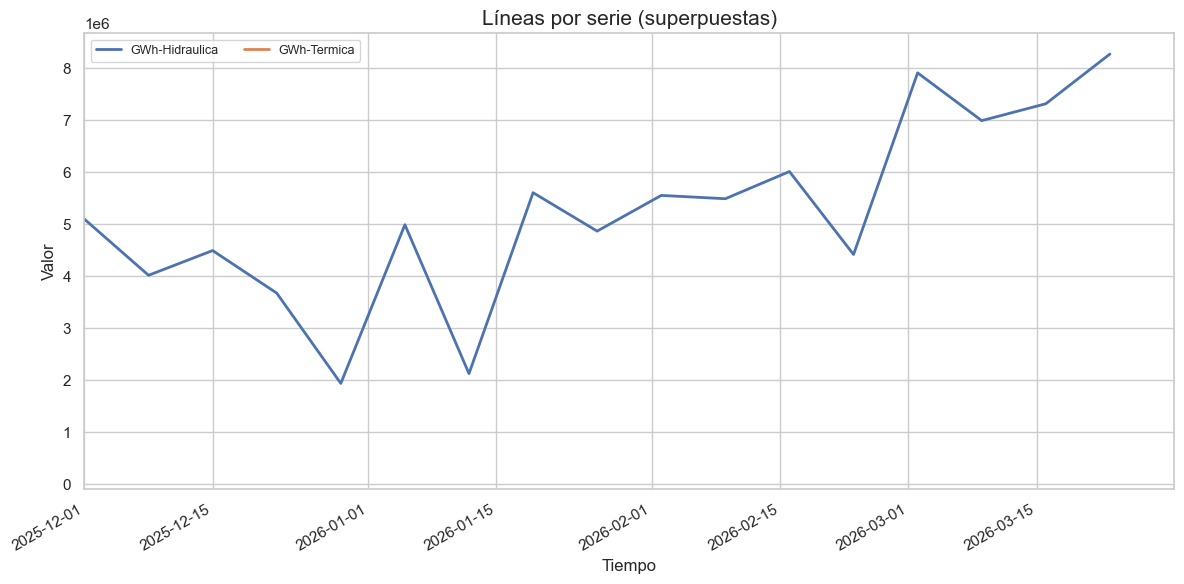

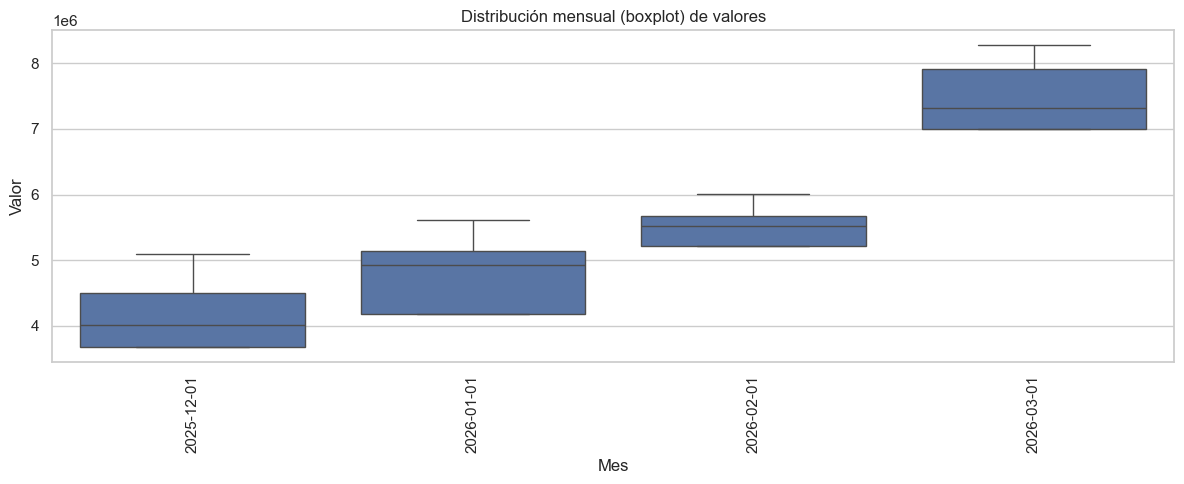

In [15]:
if len(sep) > 1:
    var = True  # apilado
else:
    var = False  # líneas superpuestas

grafica = input("Que grafica quieres generar? (lineas(1)/boxplot(2)/ambas(3)): ").lower()
if grafica == "lineas" or grafica == "1":
    plot_inteligente(sep, mostrar=["lineas"])
elif grafica == "boxplot" or grafica == "2":
    plot_inteligente(sep, mostrar=["boxplot"])
elif grafica == "ambas" or grafica == "3":
    plot_inteligente(sep, mostrar=["lineas", "boxplot"])